In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="o9gkDNhTvv9r3Uy2bdT2")
project = rf.workspace("maegan").project("rock-paper-scissors-47cyx")
version = project.version(1)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rock-Paper-Scissors-1 in yolov12:: 100%|██████████| 1633/1633 [00:00<00:00, 3899.10it/s]


In [3]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [4]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolo12n.pt')

In [5]:
results = model.train(
    data = '/content/Rock-Paper-Scissors-1/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name = 'exp1',
    device="0"
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rock-Paper-Scissors-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=None, opset=None,

In [9]:
model = YOLO('yolo12n.pt')
results = model.train(
    data='/content/Rock-Paper-Scissors-1/data.yaml',
    epochs=100,
    patience=15,
    imgsz=640,
    batch=16,

    name='exp2',
    device="0",


    degrees=15.0,
    fliplr=0.5,
    scale=0.5,
    perspective=0.0005,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rock-Paper-Scissors-1/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2-2, nbs=64, nms=None, opset=N

In [10]:
for key , value in results.results_dict.items():
  print(f"{key} : {value}")

metrics/precision(B) : 0.8971072796980663
metrics/recall(B) : 0.8164275111665874
metrics/mAP50(B) : 0.902941915296598
metrics/mAP50-95(B) : 0.573098405195117
fitness : 0.573098405195117


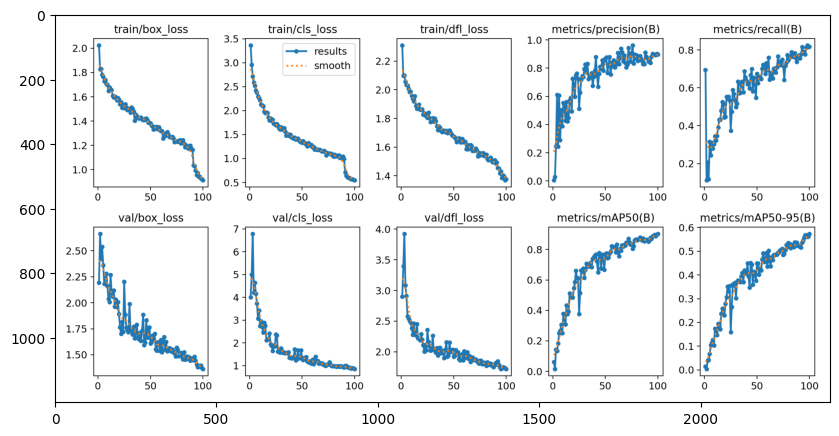

In [11]:
import matplotlib.pyplot as plt
img = plt.imread("/content/runs/detect/exp2-2/results.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

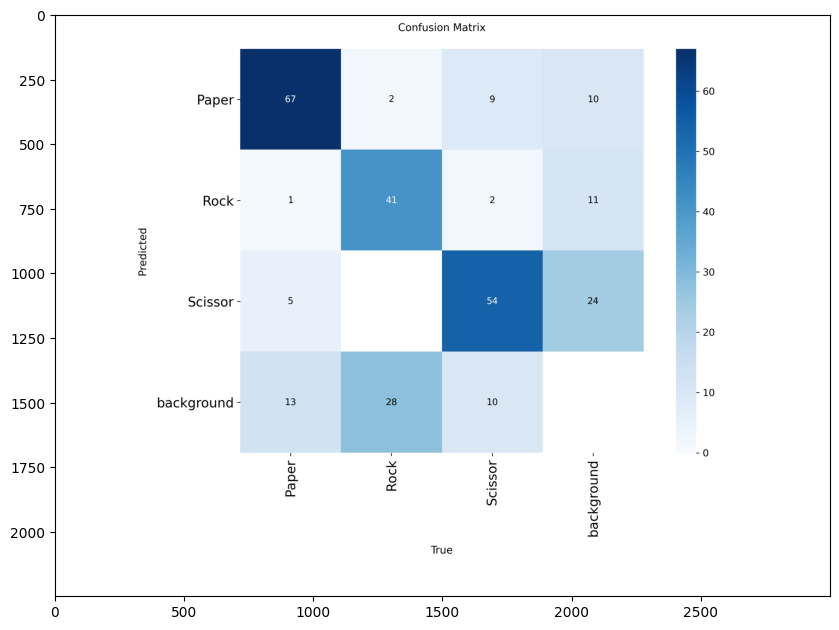

In [12]:
import matplotlib.pyplot as plt
img = plt.imread("/content/runs/detect/exp1/confusion_matrix.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

In [13]:
valid_result = model.val()

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1089.8±351.4 MB/s, size: 21.7 KB)
val: Scanning /content/Rock-Paper-Scissors-1/valid/labels.cache... 120 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 31.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.8it/s 2.9s
                   all        120        232      0.896      0.818      0.903      0.573
                 Paper         66         86      0.914      0.849      0.959      0.637
                  Rock         63         71      0.926      0.704       0.82      0.512
               Scissor         63         75      0.849        0.9      0.931      0.569
Speed: 5.0ms preprocess, 7.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/v

In [14]:
results = model.predict(source='/content/Rock-Paper-Scissors-1/test/images', save =True)


image 1/60 /content/Rock-Paper-Scissors-1/test/images/11_PNG_jpg.rf.f797313b69c56b8ea852d6c54eabab4c.jpg: 640x640 1 Rock, 1 Scissor, 12.5ms
image 2/60 /content/Rock-Paper-Scissors-1/test/images/13_png_jpg.rf.907180566066dc7f7889edfbf0515157.jpg: 640x640 2 Scissors, 11.8ms
image 3/60 /content/Rock-Paper-Scissors-1/test/images/15_png_jpg.rf.07e4e67c0281e0caf0620ece47cbbe6c.jpg: 640x640 1 Paper, 1 Rock, 1 Scissor, 17.1ms
image 4/60 /content/Rock-Paper-Scissors-1/test/images/1665130665851_jpg.rf.99850fb17f24ea4750b8e282ec53b559.jpg: 640x640 1 Scissor, 11.7ms
image 5/60 /content/Rock-Paper-Scissors-1/test/images/1665130665902_jpg.rf.dfd2984be76380abc571e9f0ff5bf5e1.jpg: 640x640 1 Scissor, 11.9ms
image 6/60 /content/Rock-Paper-Scissors-1/test/images/1665130665909_jpg.rf.a679cfc9a4b0b355d8dc4c0610531308.jpg: 640x640 1 Paper, 1 Scissor, 11.9ms
image 7/60 /content/Rock-Paper-Scissors-1/test/images/1665130666028_jpg.rf.0c3d8790da61af31292e912958496bb6.jpg: 640x640 1 Scissor, 12.0ms
image 8/60 /

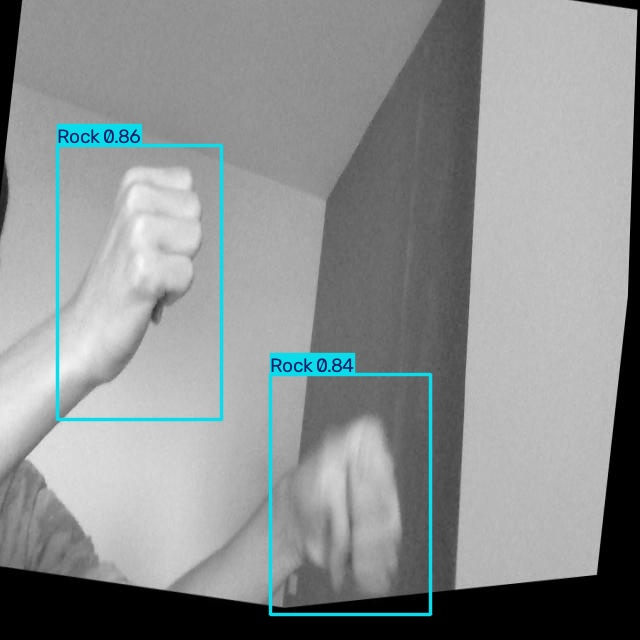

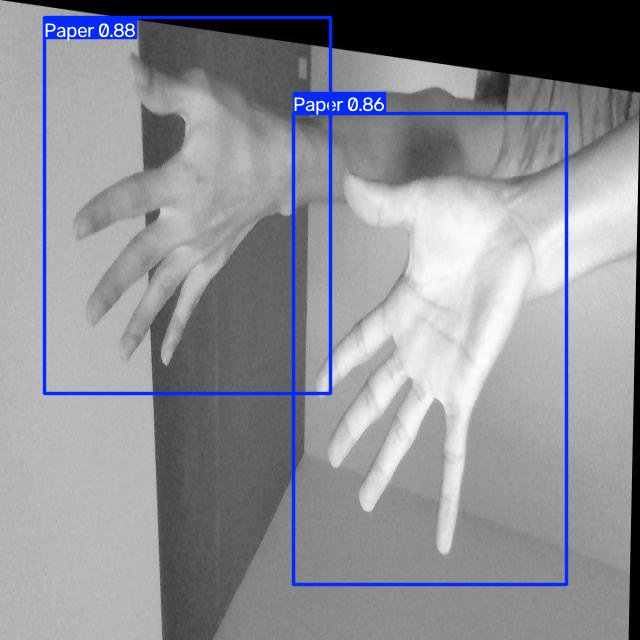

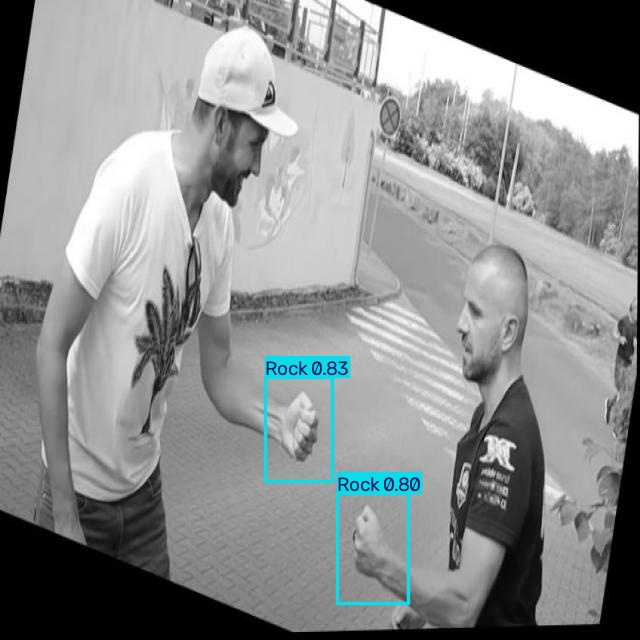

In [15]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display
i = 0
for imageName in glob.glob("runs/detect/predict/*.jpg"): #assuming JPG
    if i %25 ==0 :
        print("\n")
        display(Image(filename=imageName))
    i = i +1